In [1]:
import numpy as np
import polars as pl

df = pl.read_csv('data_neural_network_3det.csv')

In [2]:
df

TRIG,particles,composition,energy,particles_normalized
str,f64,str,f64,f64
"""TRIG3""",28.8928,"""Proton""",1.0000e15,0.123445
"""TRIG3""",1.333333,"""Iron""",1.0000e14,0.001475
"""TRIG2""",9.996997,"""Photon""",3.1600e14,0.039818
"""TRIG2""",13.835294,"""Nitrogen""",1.0000e15,0.056805
"""TRIG1""",70.216216,"""Oxygen""",3.1600e15,0.306329
…,…,…,…,…
"""TRIG1""",17.957219,"""Oxygen""",1.0000e15,0.075047
"""TRIG3""",152.422018,"""Photon""",3.1600e15,0.670145
"""TRIG1""",5.633803,"""Oxygen""",3.1600e14,0.020508


In [3]:
# Excluir a coluna particles que não está normalizada
df = df.drop('particles')
# Conversão de strings para números
mapper = {
    'Photon':1,
    'Proton':float(np.log(1)),
    'Carbon':float(np.log(12)),
    'Nitrogen':float(np.log(14)),
    'Oxygen':float(np.log(16)),
    'Iron':float(np.log(56))
}

trigs = []
for i in range(1,4):
    trig = 'TRIG' + str(i)
    trigs.append(trig)

trigs = dict((list(enumerate(trigs, 1))))

trigs = {value: key for key, value in trigs.items()}

df = df.with_columns([
    pl.col('composition').map_elements(lambda x: mapper.get(x, None), return_dtype=pl.Float64).alias('composition'),
    pl.col('TRIG').map_elements(lambda x: trigs.get(x, None), return_dtype=pl.Int64).alias('TRIG')
])

In [4]:
df

TRIG,composition,energy,particles_normalized
i64,f64,f64,f64
3,0.0,1.0000e15,0.123445
3,4.025352,1.0000e14,0.001475
2,1.0,3.1600e14,0.039818
2,2.639057,1.0000e15,0.056805
1,2.772589,3.1600e15,0.306329
…,…,…,…
1,2.772589,1.0000e15,0.075047
3,1.0,3.1600e15,0.670145
1,2.772589,3.1600e14,0.020508


In [5]:
df_grouped = df.group_by(["energy", "composition", "TRIG"]).agg([
    pl.col("particles_normalized").first()
])

df_neural = df_grouped.pivot(
    values="particles_normalized",
    index=["energy", "composition"],
    columns="TRIG"
)

# Estrutura em ordem numérica
df_neural = df_neural.select(
    ['energy', 'composition'] + [f"{i}" for i in range(1, 4)]
)

# Log da energia
    
df_neural = df_neural.with_columns(
      ((pl.col('energy').log10()))
    )

df_neural

C:\Users\Lucas\AppData\Local\Temp\ipykernel_8096\85735371.py:5: DeprecationWarning: The argument `columns` for `DataFrame.pivot` is deprecated. It has been renamed to `on`.
  df_neural = df_grouped.pivot(


energy,composition,1,2,3
f64,f64,f64,f64,f64
14.499687,2.484907,0.016702,0.015068,0.014858
14.0,2.772589,0.029715,0.008851,0.000632
15.499687,2.639057,0.393781,0.26351,0.266894
15.0,4.025352,0.039716,0.031525,0.028705
15.0,2.484907,0.099986,0.067102,0.067547
…,…,…,…,…
15.499687,1.0,1.0,0.666389,0.670145
14.0,2.484907,0.007587,0.007903,0.009167
14.0,2.639057,0.025079,0.009589,0.005901


In [6]:
columns = ['energy','composition']
y = df_neural.select(columns)
x = df_neural.select(pl.exclude(columns))

x = np.array(x)
y = np.array(y)

In [7]:
# Criação do modelo

import torch
import torch.nn as nn
import torch.optim as optim

# Arquitetura

class NeuralNetwork(nn.Module):
    def __init__(self, input_size, activation):
        super(NeuralNetwork, self).__init__()
    
        # Camadas
        self.hidden1 = nn.Linear(input_size, 64) # Primeira camada oculta
        self.hidden2 = nn.Linear(64,64) # Segunda camada oculta
        self.hidden3 = nn.Linear(64,32) # Terceira camada oculta
        self.output = nn.Linear(32,2) # Camada de saída com 2 valores contínuos
        self.activation = activation

    def forward(self,x):
        x = self.activation(self.hidden1(x))
        x = self.activation(self.hidden2(x))
        x = self.activation(self.hidden3(x))
        x = self.output(x)
        return x

In [8]:
from sklearn.model_selection import train_test_split

# Separar os dados em treino e teste
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Convertendo para tensores
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [9]:
# Treinamento do modelo

def train_model(activation_function):
    # Define a função de ativação
    if activation_function == 'tanh':
        activation = torch.tanh
    elif activation_function == 'relu':
        activation = torch.relu
    elif activation_function == 'sigmoid':
        activation = torch.sigmoid

    
    input_size = 3
    model = NeuralNetwork(input_size, activation)

    # Função perda - Erro quadrático médio

    criterion = nn.MSELoss() 

    # Otimizador Adam (Adaptive Moment Estimation)
    optimizer = optim.Adam(model.parameters(), lr = 0.001)

    loss_list = []
    test_loss_list = []

    #x_train_tensor = torch.tensor(x, dtype= torch.float32)
    #y_train_tensor = torch.tensor(y, dtype= torch.float32)

    epochs = 1000

    for epoch in range(epochs):
        # Entra no modo de treino
        model.train()
        # Zera o gradiente
        optimizer.zero_grad()
        # Faz a predição
        outputs = model(x_train_tensor)
        # Calcula o erro
        loss = criterion(outputs, y_train_tensor)
        loss_list.append(loss.item())
        # Retropropagação
        loss.backward()
        # Atualiza os parâmetros
        optimizer.step()

        # Avaliar no conjunto de teste
        model.eval()
        with torch.no_grad():
            test_outputs = model(x_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor)
            test_loss_list.append(test_loss.item())

        if (epoch+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')
            
    return model, loss_list, test_loss_list

Epoch [100/1000], Loss: 32.5531, Test Loss: 29.1057
Epoch [200/1000], Loss: 14.1414, Test Loss: 12.3714
Epoch [300/1000], Loss: 5.7527, Test Loss: 4.9417
Epoch [400/1000], Loss: 2.4104, Test Loss: 2.2387
Epoch [500/1000], Loss: 1.2988, Test Loss: 1.5143
Epoch [600/1000], Loss: 0.9955, Test Loss: 1.4226
Epoch [700/1000], Loss: 0.9280, Test Loss: 1.4594
Epoch [800/1000], Loss: 0.9158, Test Loss: 1.4934
Epoch [900/1000], Loss: 0.9140, Test Loss: 1.5099
Epoch [1000/1000], Loss: 0.9137, Test Loss: 1.5163
Epoch [100/1000], Loss: 4.5061, Test Loss: 1.6568
Epoch [200/1000], Loss: 0.9201, Test Loss: 1.3374
Epoch [300/1000], Loss: 0.8423, Test Loss: 1.4284
Epoch [400/1000], Loss: 0.6595, Test Loss: 1.6619
Epoch [500/1000], Loss: 0.6029, Test Loss: 1.9272
Epoch [600/1000], Loss: 0.5955, Test Loss: 1.9254
Epoch [700/1000], Loss: 0.5887, Test Loss: 1.9252
Epoch [800/1000], Loss: 0.5752, Test Loss: 1.9183
Epoch [900/1000], Loss: 0.5542, Test Loss: 1.9753
Epoch [1000/1000], Loss: 0.5430, Test Loss: 2

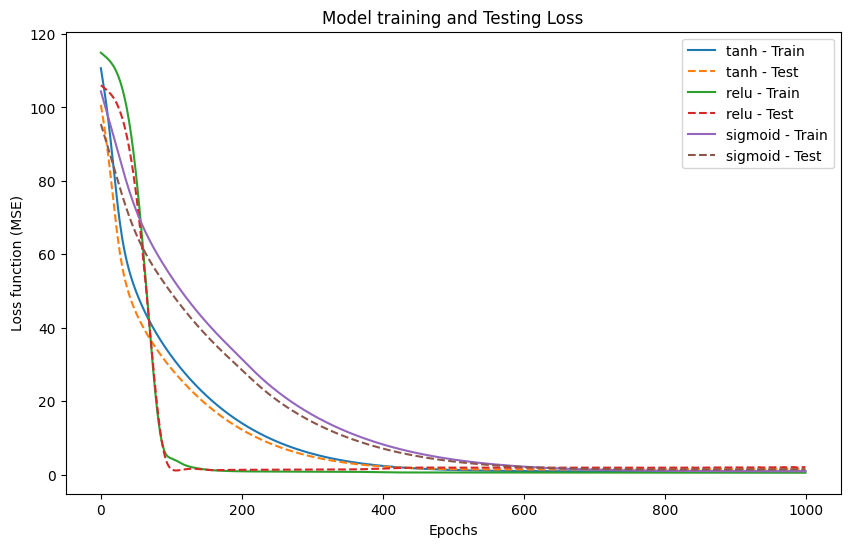

In [10]:
activation_functions = ['tanh', 'relu', 'sigmoid']
models = {}
train_losses = {}
test_losses = {}

for activation in activation_functions:
    #print(f'Treinando com função de ativação: {activation}')
    model, train_loss, test_loss = train_model(activation)
    train_losses[activation] = train_loss
    test_losses[activation] = test_loss
    models[activation] = model

import matplotlib.pyplot as plt
# Plotar os resultados
plt.figure(figsize=(10, 6))
for activation in activation_functions:
    plt.plot(train_losses[activation], label=f'{activation} - Train')
    plt.plot(test_losses[activation], label=f'{activation} - Test', linestyle = 'dashed')

plt.title('Model training and Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss function (MSE)')
plt.legend()
plt.show()

In [11]:
torch.cuda.is_available()

True

In [12]:
torch.cuda.device_count()

1

In [13]:
torch.cuda.current_device()

0

In [14]:
torch.cuda.device(0)

In [15]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce GTX 1050 Ti'